<a href="https://colab.research.google.com/github/vaibhavthakur1997/Analysis-Reports/blob/main/gpt_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

np.random.seed(42)

dates = pd.date_range(start='2025-01-01', periods=60)

regions = ['North', 'South', 'East', 'West']
products = ['Milk', 'Butter', 'Cheese', 'Curd']
categories = ['Dairy']

data = []

for i in range(200):
    data.append([
        np.random.choice(dates),
        np.random.choice(regions),
        np.random.choice(products),
        'Dairy',
        np.random.randint(100, 500),   # Sales
        np.random.randint(50, 300),    # Cost
        np.random.randint(1000, 1100)  # Customer_ID
    ])

df = pd.DataFrame(data, columns=[
    'Date','Region','Product','Category','Sales','Cost','Customer_ID'
])

df.head()

,Date,Region,Product,Category,Sales,Cost,Customer_ID
0,2025-02-08,West,Milk,Dairy,370,156,1071
1,2025-01-21,East,Butter,Dairy,314,124,1074
2,2025-01-24,North,Curd,Dairy,459,201,1002
3,2025-01-22,North,Butter,Dairy,443,285,1029
4,2025-02-07,South,Curd,Dairy,376,210,1075


In [ ]:
df

,Date,Region,Product,Category,Sales,Cost,Customer_ID
0,2025-02-08,West,Milk,Dairy,370,156,1071
1,2025-01-21,East,Butter,Dairy,314,124,1074
2,2025-01-24,North,Curd,Dairy,459,201,1002
3,2025-01-22,North,Butter,Dairy,443,285,1029
4,2025-02-07,South,Curd,Dairy,376,210,1075
...,...,...,...,...,...,...,...
195,2025-01-10,East,Milk,Dairy,208,195,1099
196,2025-02-16,South,Butter,Dairy,210,57,1039
197,2025-02-18,West,Cheese,Dairy,141,218,1005
198,2025-02-21,South,Curd,Dairy,325,236,1055


In [ ]:
df['Date'] = pd.to_datetime(df['Date'])
df['Profit'] = df['Sales'] - df['Cost']
df['Month'] = df['Date'].dt.to_period('M')

In [ ]:
df

,Date,Region,Product,Category,Sales,Cost,Customer_ID,Profit,Month
0,2025-02-08,West,Milk,Dairy,370,156,1071,214,2025-02
1,2025-01-21,East,Butter,Dairy,314,124,1074,190,2025-01
2,2025-01-24,North,Curd,Dairy,459,201,1002,258,2025-01
3,2025-01-22,North,Butter,Dairy,443,285,1029,158,2025-01
4,2025-02-07,South,Curd,Dairy,376,210,1075,166,2025-02
...,...,...,...,...,...,...,...,...,...
195,2025-01-10,East,Milk,Dairy,208,195,1099,13,2025-01
196,2025-02-16,South,Butter,Dairy,210,57,1039,153,2025-02
197,2025-02-18,West,Cheese,Dairy,141,218,1005,-77,2025-02
198,2025-02-21,South,Curd,Dairy,325,236,1055,89,2025-02


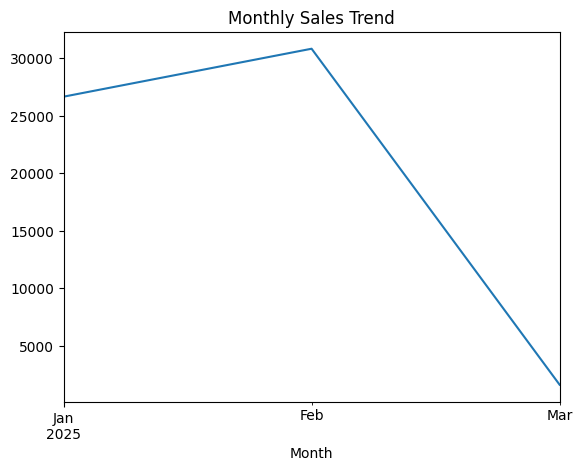

In [ ]:
import matplotlib.pyplot as plt

monthly_sales = df.groupby('Month')['Sales'].sum()

monthly_sales.plot()
plt.title('Monthly Sales Trend')
plt.show()

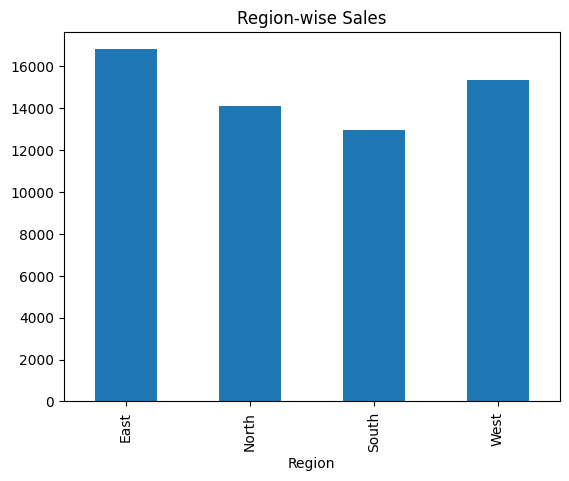

In [ ]:
region_sales = df.groupby('Region')['Sales'].sum()

region_sales.plot(kind='bar')
plt.title('Region-wise Sales')
plt.show()

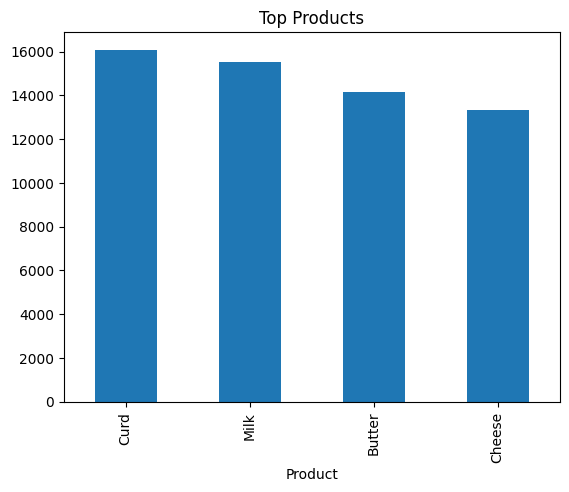

In [ ]:
product_sales = df.groupby('Product')['Sales'].sum().sort_values(ascending=False)

product_sales.plot(kind='bar')
plt.title('Top Products')
plt.show()

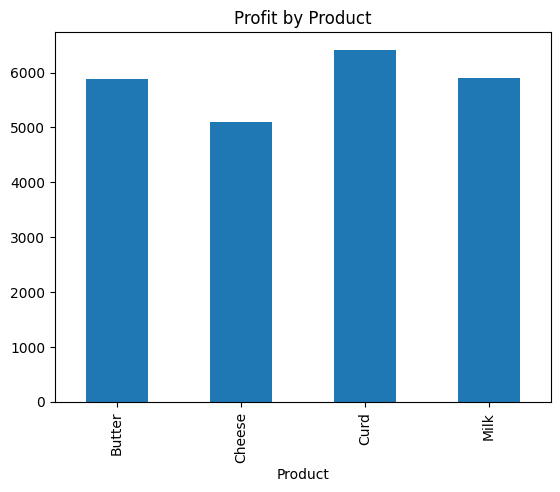

In [ ]:
profit_analysis = df.groupby('Product')['Profit'].sum()

profit_analysis.plot(kind='bar')
plt.title('Profit by Product')
plt.show()

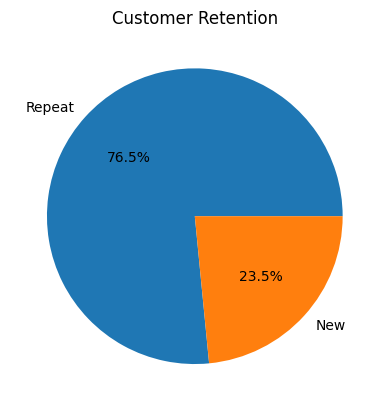

In [ ]:
customer_counts = df['Customer_ID'].value_counts()

repeat = (customer_counts > 1).sum()
new = (customer_counts == 1).sum()

plt.pie([repeat, new], labels=['Repeat','New'], autopct='%1.1f%%')
plt.title('Customer Retention')
plt.show()